# H1N1 and Seasonal Flu Vaccines

## Project Overview

This project focuses on whether individuals received the H1NI flu vaccine (or alternatively the seasonal flu vaccine) using data from the National 2009 H1N1 Flu Survey. The dataset contain demographic information, health-related behaviours and public perceptions about the vaccines. 
The goal is to build a binary classification modelthat estimates the probability of vaccination for each individual.By analyzing patterns in the data, the model will identify key factors influencing vaccination uptake. This project is especially relevant in the context of global vaccination campaigns, where understanding public behaviourcan help improve vaccine distribution strategies, increase uptake and reduce the spread of infectious diseases.

## Business Understanding

Vaccination is a critical tool in controlling infectous diseses, but uptake often varies across populations due to differences in beleifs, access, awareness, and socio-demographic factors. Public health organizations face challenges such as:
- Vaccine hesitancy
- Unequal access to healthcare services
- Misinformation and lack of trust
- Inefficient targeting of high-risk populations

By predicting who is more or less likely to get vaccinated, this project provides data driven insights that can help:
- Target awareness campaigns more effectively
- Allocate resources efficiently
- Design policies to increase vaccination rates
- Identify vulnarable or hesitant groups early

#### Stakeholders

The key stakeholders who will benefit from this project include:
1. Public Health Organizations- Use insights to design vaccines campaigns 
2. Government Policy Makers- Develop policies to improve vaccination coverage 
3. Healthcare Providers and Hospitals- Identify patients who may need encouragement or education 

#### Key Questions

The project seeks to answer the following questions:
1. What factors influence whether a person get vaccinated?
2. Can we accurately predict vaccination behaviour using demographic and behavioural data?
3. Which groups are least likely to receive the vaccine?
4. How do perceptions(e.g risk, trust in vaccines) affect vaccination decisions?
5. What features are strongest predictors of vaccine uptake?

#### Objectives

The main objective of this project is:
- To build a predictive classification model that estimates the likelihood of an individual receiving the H1N1 vaccine or the Seasonal Flu Vaccine.



## Data Understanding

In [836]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [837]:
# Reading the dataset into a pandas dataframe 
df=pd.read_csv("H1N1_Flu_Vaccines.csv")
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [838]:
# chhecking the shape of the dataset
df.shape

(26707, 38)

The dataset has 26707 rows and 38 columns.

In [839]:
# checking the infomation of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [840]:
# checking the missing values 
df.isna().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_seasonal            2160
doctor_recc_h1n1                2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_children               249
household_adults                 249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

In [841]:
# Checkingthe summary statistics of the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.0,13353.000000,7709.791156,0.0,6676.5,13353.0,20029.5,26706.0
h1n1_concern,26615.0,1.618486,0.910311,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.262532,0.618149,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.048844,0.215545,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.725612,0.446214,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.068982,0.253429,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.825614,0.379448,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.358640,0.479610,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,26625.0,0.337315,0.472802,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,26579.0,0.677264,0.467531,0.0,0.0,1.0,1.0,1.0


In [842]:
# Find the duplicated rows
df.duplicated().sum()

np.int64(0)

The dataset hs no duplicated rows.

### Class Distribution

In [843]:
# Check the distribution of the target variable for H1N1 vaccine uptake
print(df["h1n1_vaccine"].value_counts())

# Check the distribution of the target variable for seasonal flu vaccine uptake
print(df["seasonal_vaccine"].value_counts())

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


From the above output, we can see that the h1n1 vaccine target class is imbalanced. The seasonal vaccine class is more balanced, but we'll have to keep tabs on this once we start modeling. A very small rate of people received both seasonal as well as h1n1 vaccines.

Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.

In [844]:
# Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.
only_h1n1 = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

only_seasonal = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

both = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

neither = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

# print results
print("Only H1N1:", only_h1n1)
print("Only Seasonal:", only_seasonal)
print("Both Vaccines:", both)
print("Neither:", neither)

Only H1N1: 0.03658216946867862
Only Seasonal: 0.2897367731306399
Both Vaccines: 0.17587149436477328
Neither: 0.4978095630359082


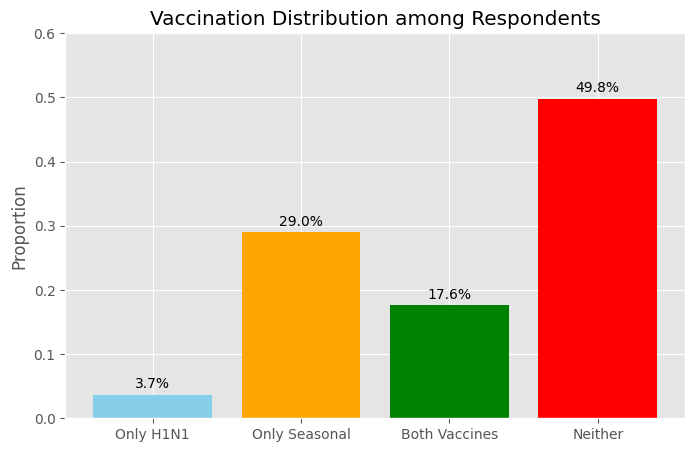

In [845]:
# categories and their proportions
categories = ["Only H1N1", "Only Seasonal", "Both Vaccines", "Neither"]
proportions = [0.0366, 0.2897, 0.1759, 0.4978]

# create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(categories, proportions, color=['skyblue','orange','green','red'])
plt.title("Vaccination Distribution among Respondents")
plt.ylabel("Proportion")
plt.ylim(0, 0.6)

# add percentage labels on top of bars
for bar, prop in zip(bars, proportions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{prop*100:.1f}%", ha='center', fontsize=10)

plt.show()



From the above vaccination distribution analysis, about 3.7% of respondents took only the H1N1 vaccine, 29.0% took only the seasonal vaccine, 17.6% took both, and 49.8% took neither, showing that almost half did not receive any vaccine.

## 3. Data preparation

##### Dropping Columns with Many Missing Values

In this step, we remove columns that contain a large number of missing values.


In [846]:
# drop the columns with many missing values 
df.drop(["employment_occupation", "employment_industry", "health_insurance", "respondent_id", "doctor_recc_seasonal"], axis=1, inplace=True)

##### Splitting Features and Target Variables

In this step, we separate the dataset into input features (`X`) and target variables (`y`).

In [847]:
x=df.drop(["h1n1_vaccine", "seasonal_vaccine"], axis=1)
y=df["h1n1_vaccine"]

For this project, the target variable selected is h1n1_vaccine, which indicates whether an individual received the H1N1 vaccine (1) or not (0).

##### Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate the model's performance.

In [848]:
# splitting the dataset into training and testing
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((21365, 31), (5342, 31), (21365,), (5342,))

Data preparation for the x_train

In [849]:
x_train.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,White,Female,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,White,Male,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,White,Male,NaN,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Other or Multiple,Female,NaN,Not Married,Own,Employed,bhuqouqj,Non-MSA,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,1.0


In [850]:
# checking for missing values in the x_train dataset
print(x_train.isna().sum().sort_values(ascending=False))


income_poverty                 3514
doctor_recc_h1n1               1736
rent_or_own                    1628
employment_status              1162
education                      1125
marital_status                 1120
chronic_med_condition           771
child_under_6_months            655
health_worker                   643
opinion_seas_sick_from_vacc     431
opinion_seas_risk               410
opinion_seas_vacc_effective     371
opinion_h1n1_sick_from_vacc     321
opinion_h1n1_vacc_effective     318
opinion_h1n1_risk               311
household_adults                202
household_children              202
behavioral_avoidance            163
behavioral_touch_face           102
h1n1_knowledge                   91
h1n1_concern                     73
behavioral_large_gatherings      72
behavioral_antiviral_meds        59
behavioral_outside_home          59
behavioral_wash_hands            36
behavioral_face_mask             14
age_group                         0
sex                         

In [851]:
# checking for missing values in the x_test dataset
print(x_test.isna().sum().sort_values(ascending=False))

income_poverty                 909
doctor_recc_h1n1               424
rent_or_own                    414
employment_status              301
marital_status                 288
education                      282
chronic_med_condition          200
child_under_6_months           165
health_worker                  161
opinion_seas_sick_from_vacc    106
opinion_seas_risk              104
opinion_seas_vacc_effective     91
opinion_h1n1_risk               77
opinion_h1n1_sick_from_vacc     74
opinion_h1n1_vacc_effective     73
household_adults                47
household_children              47
behavioral_avoidance            45
behavioral_touch_face           26
h1n1_knowledge                  25
behavioral_outside_home         23
h1n1_concern                    19
behavioral_large_gatherings     15
behavioral_antiviral_meds       12
behavioral_wash_hands            6
behavioral_face_mask             5
age_group                        0
sex                              0
race                

#### Handling missing values for the x_train and the x_test

Ordinal numerical columns

In [852]:
# handling missing values for the numerical columns
x_train.select_dtypes("float64").isna().sum()


h1n1_concern                     73
h1n1_knowledge                   91
behavioral_antiviral_meds        59
behavioral_avoidance            163
behavioral_face_mask             14
behavioral_wash_hands            36
behavioral_large_gatherings      72
behavioral_outside_home          59
behavioral_touch_face           102
doctor_recc_h1n1               1736
chronic_med_condition           771
child_under_6_months            655
health_worker                   643
opinion_h1n1_vacc_effective     318
opinion_h1n1_risk               311
opinion_h1n1_sick_from_vacc     321
opinion_seas_vacc_effective     371
opinion_seas_risk               410
opinion_seas_sick_from_vacc     431
household_adults                202
household_children              202
dtype: int64

In [853]:
x_test.select_dtypes("float64").isna().sum()

h1n1_concern                    19
h1n1_knowledge                  25
behavioral_antiviral_meds       12
behavioral_avoidance            45
behavioral_face_mask             5
behavioral_wash_hands            6
behavioral_large_gatherings     15
behavioral_outside_home         23
behavioral_touch_face           26
doctor_recc_h1n1               424
chronic_med_condition          200
child_under_6_months           165
health_worker                  161
opinion_h1n1_vacc_effective     73
opinion_h1n1_risk               77
opinion_h1n1_sick_from_vacc     74
opinion_seas_vacc_effective     91
opinion_seas_risk              104
opinion_seas_sick_from_vacc    106
household_adults                47
household_children              47
dtype: int64


All the ordinal numerical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column. This method is appropriate because ordinal features represent ordered categories, and using the mode helps preserve the most common and meaningful responses without changing the data.

In [854]:
# selecting the columns with float data types
x_train_float=x_train.select_dtypes('float64')
x_test_float=x_test.select_dtypes("float64")


# initializing the simple imputer class and using the mode strategy to fill the missing values
imputer=SimpleImputer(strategy="most_frequent")
imputer.fit(x_train_float)
x_train_filled_float=pd.DataFrame(imputer.transform(x_train_float), index=x_train_float.index, 
                          columns=x_train_float.columns)
x_test_filled_float=pd.DataFrame(imputer.transform(x_test_float), index=x_test_float.index, 
                          columns=x_test_float.columns)
x_train_float= x_train_filled_float
x_test_float= x_test_filled_float

In [855]:
x_train_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

In [856]:
x_test_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

#### Handling missing values for the categorical columns


Some categorical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column.



In [857]:
x_train_cat= x_train.select_dtypes("object")
x_train_cat.isna().sum()

age_group               0
education            1125
race                    0
sex                     0
income_poverty       3514
marital_status       1120
rent_or_own          1628
employment_status    1162
hhs_geo_region          0
census_msa              0
dtype: int64

In [858]:
x_test_cat=x_test.select_dtypes("object")
x_test_cat.isna().sum()

age_group              0
education            282
race                   0
sex                    0
income_poverty       909
marital_status       288
rent_or_own          414
employment_status    301
hhs_geo_region         0
census_msa             0
dtype: int64

In [859]:
# selecting the x_train columns with string data types
x_train_cat= x_train.select_dtypes("object")
x_test_cat=x_test.select_dtypes("object")

# creating a variable called cat_cols that has the columns with the missing values
cat_cols=["education","income_poverty", "marital_status","rent_or_own","employment_status"]

# filling the missing values with the mode strategy using the simpleimputer method
imputer=SimpleImputer(strategy="most_frequent")
imputer.fit(x_train_cat[cat_cols])
x_train_cat_filled=pd.DataFrame(imputer.transform(x_train_cat[cat_cols]), index=x_train_cat[cat_cols].index, 
                        columns=x_train_cat[cat_cols].columns)

x_test_cat_filled=pd.DataFrame(imputer.transform(x_test_cat[cat_cols]), index=x_test_cat[cat_cols].index, 
                        columns=x_test_cat[cat_cols].columns)

x_train_cat_filled= x_train_cat_filled
x_test_cat_filled= x_test_cat_filled


In [860]:
x_train_cat_filled.isna().sum()

education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [861]:
x_test_cat_filled.isna().sum()

education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [862]:
# Concatinating the filled columns to form one x_train dataframe 
x_train_full=pd.concat([x_train_float, x_train_cat_filled, 
                       x_train_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,Below Poverty,Married,Rent,Unemployed,45 - 54 Years,White,Female,"MSA, Not Principle City",lzgpxyit
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"> $75,000",Not Married,Own,Employed,45 - 54 Years,White,Male,"MSA, Not Principle City",lzgpxyit
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Not Principle City",qufhixun
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Employed,45 - 54 Years,Other or Multiple,Female,Non-MSA,bhuqouqj
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,65+ Years,Black,Female,"MSA, Principle City",mlyzmhmf


In [863]:
# Concatinating the filled columnst to form one x_train dataframe 
x_test_full=pd.concat([x_test_float, x_test_cat_filled, 
                       x_test_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [864]:
x_test_full["rent_or_own"].isna().sum()

np.int64(0)

### Mapping the Categorical columns

Mapping the train columns

In [865]:
x_train_full["education"].unique()

<StringArray>
['Some College', 'College Graduate', '12 Years', '< 12 Years']
Length: 4, dtype: str

In [866]:
x_train_full["education"]=x_train_full["education"].replace({"12 Years": "Secondary School", "< 12 Years":"Primary School"})

x_train_full["education"].unique()

<StringArray>
['Some College', 'College Graduate', 'Secondary School', 'Primary School']
Length: 4, dtype: str

In [867]:
x_train_full["income_poverty"].unique()

<StringArray>
['Below Poverty', '> $75,000', '<= $75,000, Above Poverty']
Length: 3, dtype: str

In [868]:
x_train_full["income_poverty"]=x_train_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_train_full["income_poverty"].unique()

<StringArray>
['Low Income', 'High_income', 'Average Income']
Length: 3, dtype: str

Mapping the test data

In [869]:
x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', '12 Years', '< 12 Years']
Length: 4, dtype: str

In [870]:
x_test_full["education"]=x_test_full["education"].replace({"12 Years": "Secondary School", "< 12 Years":"Primary School"})

x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', 'Secondary School', 'Primary School']
Length: 4, dtype: str

In [871]:
x_test_full["income_poverty"].unique()

<StringArray>
['<= $75,000, Above Poverty', '> $75,000', 'Below Poverty']
Length: 3, dtype: str

In [872]:
x_test_full["income_poverty"]=x_test_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_test_full["income_poverty"].unique()

<StringArray>
['Average Income', 'High_income', 'Low Income']
Length: 3, dtype: str

In [873]:
x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,High_income,Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,High_income,Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [874]:
x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,Low Income,Married,Rent,Unemployed,45 - 54 Years,White,Female,"MSA, Not Principle City",lzgpxyit
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,High_income,Not Married,Own,Employed,45 - 54 Years,White,Male,"MSA, Not Principle City",lzgpxyit
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Not Principle City",qufhixun
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,Average Income,Not Married,Own,Employed,45 - 54 Years,Other or Multiple,Female,Non-MSA,bhuqouqj
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,Average Income,Not Married,Own,Not in Labor Force,65+ Years,Black,Female,"MSA, Principle City",mlyzmhmf


In [875]:
# Preventive behavior score
x_train_full["preventive_behavior"] = (
    x_train_full["behavioral_antiviral_meds"] +
    x_train_full["behavioral_avoidance"] +
    x_train_full["behavioral_face_mask"] +
    x_train_full["behavioral_wash_hands"]
)

x_test_full["preventive_behavior"] = (
    x_test_full["behavioral_antiviral_meds"] +
    x_test_full["behavioral_avoidance"] +
    x_test_full["behavioral_face_mask"] +
    x_test_full["behavioral_wash_hands"]
)



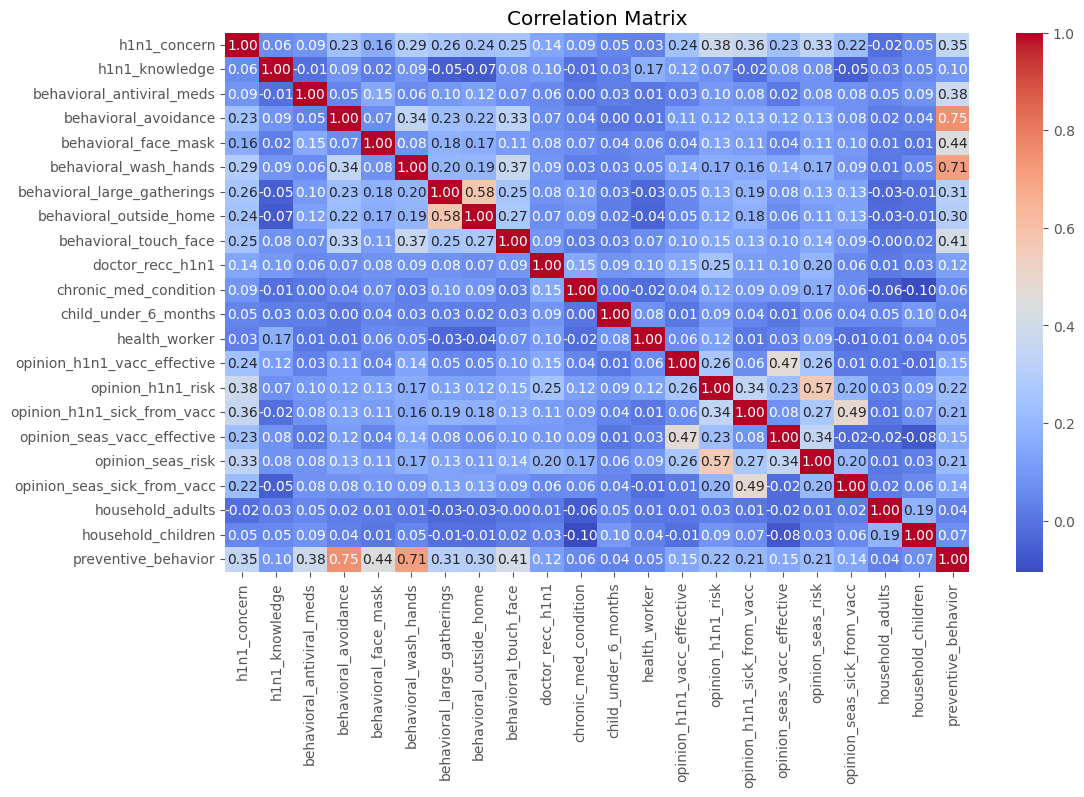

In [876]:
# Creating a correlation matrix 
# Keep only numeric columns
numeric_cols = x_train_full.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

A correlation analysis showed that these new features were highly correlated with their original components. To reduce redundancy and multicollinearity, the original columns contributing to these sums need to be dropped. This ensures the dataset is more compact while retaining the key information for modeling.

In [877]:
cols_to_drop = [
    "behavioral_antiviral_meds", 
    "behavioral_avoidance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
]

x_train_full = x_train_full.drop(columns=cols_to_drop)
x_test_full = x_test_full.drop(columns=cols_to_drop)

The selected features were dropped from both training and testing datasets. These columns are removed because they may be redundant, highly correlated, or already captured through engineered features (e.g., preventive_behavior), which helps reduce multicollinearity and simplify the model.

### OneHotEncoding the Categorical columns

One Hot Encoding the train data


In [878]:
print(x_train.select_dtypes("object").columns)
print(x_test.select_dtypes("object").columns)

Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')
Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')


In [879]:
# Initializing the onehotencoder class
ohe=OneHotEncoder(sparse_output=False, drop="first")

# creating a variable called ohe_columns that contain the columns to be encoded
ohe_cols=['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa']
ohe.fit(x_train_full[ohe_cols])
x_train_ohe=pd.DataFrame(ohe.transform(x_train_full[ohe_cols]), index=x_train_full[ohe_cols].index,
                         columns=ohe.get_feature_names_out())

x_test_ohe=pd.DataFrame(ohe.transform(x_test_full[ohe_cols]), index=x_test_full[ohe_cols].index,
                         columns=ohe.get_feature_names_out())

x_train_ohe.head()

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_Primary School,education_Secondary School,education_Some College,race_Hispanic,race_Other or Multiple,race_White,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5393,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3429,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8731,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [880]:
x_test_ohe.head()

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_Primary School,education_Secondary School,education_Some College,race_Hispanic,race_Other or Multiple,race_White,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
15772,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [881]:
x_train_full=x_train_full.drop(ohe_cols, axis=1)
x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior
24706,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,4.0,2.0,4.0,4.0,2.0,1.0,0.0,2.0
5393,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,5.0,4.0,4.0,5.0,4.0,4.0,0.0,0.0,4.0
20898,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,1.0,4.0,2.0,2.0,0.0,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,5.0,5.0,2.0,5.0,1.0,1.0,1.0


In [882]:
x_test_full=x_test_full.drop(ohe_cols, axis=1)
x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior
15772,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,2.0,1.0,1.0,0.0,3.0
9407,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,2.0,1.0,1.0,1.0,3.0
16515,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,4.0,4.0,1.0,0.0,1.0,2.0
23353,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,2.0,4.0,2.0,1.0,1.0,2.0,2.0
10008,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,2.0,2.0,4.0,1.0,2.0,1.0,0.0,2.0


In [883]:
X_train_full=pd.concat([x_train_full, x_train_ohe], axis=1)
X_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8731,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [884]:
X_test_full=pd.concat([x_test_full, x_test_ohe], axis=1)
X_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA
15772,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Scaling the data using the Standard Scaler

In [885]:
# Specifying the columns to be scaled
cols_to_scale = [
    'h1n1_knowledge',
    'opinion_h1n1_vacc_effective',
    'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective',
    'opinion_seas_risk',
    'opinion_seas_sick_from_vacc',
    'household_adults',
    'household_children',
    "h1n1_concern",
    "opinion_h1n1_risk"
]

X_train_scaled = X_train_full.copy()
X_test_scaled = X_test_full.copy()

# Instanciating the standardscaler class
sc = StandardScaler()

X_train_scaled[cols_to_scale] = sc.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = sc.transform(X_test_scaled[cols_to_scale])

#### Handling class imbalance for the target variable Using SMOTE Method

In [886]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

h1n1_vaccine
0    16821
1     4544
Name: count, dtype: int64
h1n1_vaccine
0    0.787316
1    0.212684
Name: proportion, dtype: float64


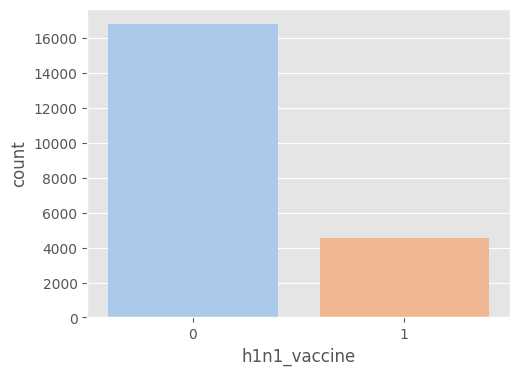

In [887]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.countplot(x=y_train, palette='pastel')
plt.show()

The target variable (`h1n1_vaccine`) shows a clear class imbalance. The majority class (0 – individuals who did not receive the vaccine) has 14,714 observations, while the minority class (1 – individuals who received the vaccine) has only 3,980 observations.

This imbalance indicates that the dataset is skewed toward the non-vaccinated group. As a result, machine learning models trained on this data may become biased toward predicting the majority class, potentially reducing the model’s ability to correctly identify vaccinated individuals. 

In [888]:
smote=SMOTE(random_state=42)
X_train_full_smote, y_train_smote=smote.fit_resample(X_train_scaled, y_train)
pd.Series(y_train_smote).value_counts()

h1n1_vaccine
0    16821
1    16821
Name: count, dtype: int64

In [889]:
X_train_full.shape, X_test_full.shape, y_train.shape, y_test.shape

((21365, 46), (5342, 46), (21365,), (5342,))

## Model creation

### Creating a model with imbalanced dataset


In [898]:
model=LogisticRegression(solver="liblinear")
model.fit(X_train_full, y_train)

scores=model.decision_function(X_test_scaled)
fpr_smote, tpr_smote, thresholds_smote=roc_curve(y_test, scores)

auc=roc_auc_score(y_test, scores)
print(auc)

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8211775878442547
[[4212    0]
 [1130    0]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      4212
           1       0.00      0.00      0.00      1130

    accuracy                           0.79      5342
   macro avg       0.39      0.50      0.44      5342
weighted avg       0.62      0.79      0.70      5342



The initial Logistic Regression model trained on the original dataset predicted only the majority class (no vaccine), resulting in zero recall for the minority class (vaccine). This occurred due to class imbalance, where approximately 79% of observations belong to class 0 and only 21% to class 1.

Although the model achieved a relatively high ROC-AUC score, it failed to correctly classify individuals who received the H1N1 vaccine, demonstrating that accuracy and AUC alone can be misleading in imbalanced datasets.

To address this issue, SMOTE resampling technique was used to balance the dataset, enabling the model to better learn patterns associated with the minority class and improve its predictive performance.

### Creating a model with balanced dataset 

In [ ]:
# Set figure style
plt.style.use('ggplot')

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    
    y_pred = model.predict(X_test)
    
    print(f"\n===== {model_name} =====")
    print(f"AUC Score: {auc:.3f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return fpr, tpr, auc

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
smote_model = LogisticRegression(solver="liblinear")

# Evaluate the model using a custom evaluation function
fpr_log, tpr_log, auc_log = evaluate_model(
    smote_model,              # Model to train
    X_train_full_smote,       # Training features after SMOTE (balanced dataset)
    y_train_smote,            # Training labels after SMOTE
    X_test_scaled,            # Scaled test features
    y_test,                   # True test labels
    model_name="Logistic Regression (SMOTE)"  
)



===== Logistic Regression (SMOTE) =====
AUC Score: 0.821
Confusion Matrix:
[[3373  839]
 [ 342  788]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.70      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



#### Logistic Regression (SMOTE) Results

The Logistic Regression model trained on SMOTE-balanced data achieved an AUC score of **0.821**, indicating good overall classification performance. The model demonstrates a strong ability to identify the positive class (class 1), with a recall of **0.70**, meaning it successfully captures most of the actual positive cases.

However, this comes at the cost of lower precision (**0.48**), indicating a higher number of false positives. The overall accuracy of the model is **78%**, with a weighted F1-score of **0.79**, showing a reasonable balance between precision and recall. This performance suggests that applying SMOTE improved the model’s sensitivity to the minority class, making it more effective for problems where detecting positive cases is important.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Evaluate the model using the custom evaluation function
fpr_tree, tpr_tree, auc_tree = evaluate_model(
    decision_tree_model,      # Model to train
    X_train_full_smote,       # Training features after SMOTE (balanced dataset)
    y_train_smote,            # Training labels after SMOTE
    X_test_scaled,            # Scaled test features
    y_test,                   # True test labels
    model_name="Decision Tree"
)


===== Decision Tree =====
AUC Score: 0.649
Confusion Matrix:
[[3524  688]
 [ 608  522]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4212
           1       0.43      0.46      0.45      1130

    accuracy                           0.76      5342
   macro avg       0.64      0.65      0.65      5342
weighted avg       0.76      0.76      0.76      5342



#### Decision Tree Results

The Decision Tree model trained on SMOTE-balanced data achieved an **AUC score of 0.649**, indicating moderate ability to distinguish between classes. The model shows strong performance for the majority class (class 0), with precision and recall around **0.85** and **0.84**, respectively.  

However, the minority class (class 1) is less well predicted, with precision **0.43** and recall **0.46**, leading to a lower F1-score of **0.45**. Overall accuracy is **76%**, with a weighted F1-score of **0.76**.  These results suggest that while the Decision Tree captures the majority class well, it struggles to correctly identify positive cases, making it less effective than Logistic Regression for imbalanced data, even after SMOTE.

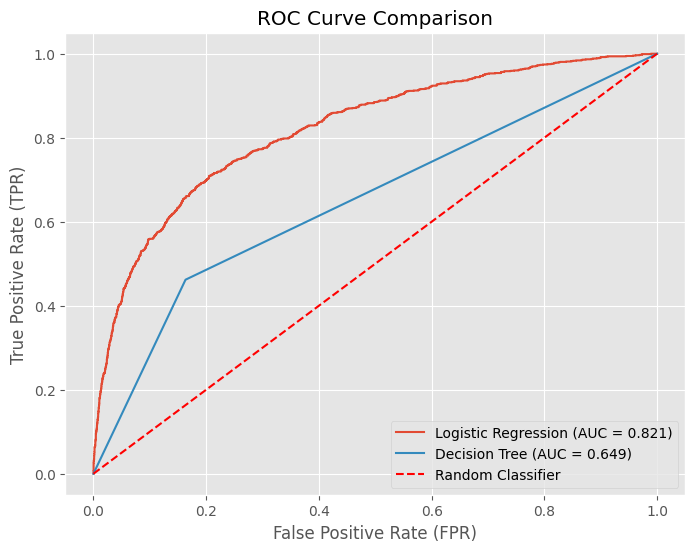

In [902]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--', color='red', label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#### ROC Curve Comparison

The ROC curve compares the performance of the Logistic Regression and Decision Tree models on the test set. 

- **Logistic Regression** (red curve) achieves an **AUC of 0.821**, indicating strong ability to distinguish between the positive and negative classes.  
- **Decision Tree** (blue curve) has a lower **AUC of 0.649**, showing moderate performance and less effectiveness at identifying the positive class.  
- The **dashed red line** represents a random classifier (AUC = 0.5) for reference.  

From the plot, it is clear that Logistic Regression outperforms the Decision Tree in classifying both majority and minority classes, making it the better model for this imbalanced dataset.

In [ ]:
# Hyperparameter grid
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Grid Search
grid_logreg = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear'),
    param_grid=logreg_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

# Fit on SMOTE training data
grid_logreg.fit(X_train_full_smote, y_train_smote)

# Best parameters
print("Best Logistic Regression Params:", grid_logreg.best_params_)
print("Best CV AUC Score:", grid_logreg.best_score_)

# Get the best tuned model
tuned_logreg = grid_logreg.best_estimator_

# Evaluate using your existing function
fpr_log_tuned, tpr_log_tuned, auc_log_tuned = evaluate_model(
    tuned_logreg,
    X_train_full_smote,
    y_train_smote,
    X_test_scaled,
    y_test,
    model_name="Tuned Logistic Regression (SMOTE)"
)

Best Logistic Regression Params: {'C': 1, 'penalty': 'l1'}
Best CV AUC Score: 0.8453366327404632

===== Tuned Logistic Regression (SMOTE) =====
AUC Score: 0.821
Confusion Matrix:
[[3375  837]
 [ 343  787]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.70      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



In [896]:
# # Hyperparameter grid
# dt_params = {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'criterion': ['gini', 'entropy']
# }

# grid_dt = GridSearchCV(
#     estimator=DecisionTreeClassifier(random_state=42),
#     param_grid=dt_params,
#     scoring='roc_auc',
#     cv=5,
#     n_jobs=-1
# )

# # Fit on SMOTE training data
# grid_dt.fit(X_train_full_smote, y_train_smote)

# # Best parameters
# print("Best Decision Tree Params:", grid_dt.best_params_)
# print("Best CV AUC Score:", grid_dt.best_score_)

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV AUC Score: 0.9151368603850522


In [897]:
# evaluate_model(grid_dt.best_estimator_, X_train_full_smote, y_train_smote, X_test_scaled, y_test, model_name="Tuned Decision Tree")